> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 5. Data Preprocessing

*Scope:* Turning a raw table into something a model can be fitted on — without letting the test set influence a single decision.

Chapter 4 found the problems. This chapter fixes them, and the order in which the fixes happen matters more
than any individual choice — which is why 5.1 comes before everything else.

One rule governs the whole chapter: **anything learned from data must be learned from the training set
only.** A mean used for imputation, a standard deviation used for scaling, a category list used for
encoding — each is a *parameter estimated from data* (1.4), and estimating it from the test set is
leakage, however innocent it looks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")

customers = pd.read_csv("data/customers.csv").drop_duplicates()
print(customers.shape)

(1000, 14)


### 5.1 The Split Comes First

The test set exists to answer one question: *how will this model do on data it has never seen?* Every time
information from the test set reaches the training process, that question gets a little less honest, and
the answer gets a little more optimistic.

The mechanism is easy to miss because it is arithmetic, not code duplication. Scaling on the whole dataset
computes a mean over *all* rows — so the training data has been shifted using a number that encodes
something about the test rows.

In [2]:
train, test = train_test_split(
    customers, test_size=0.2, stratify=customers["churned"], random_state=RANDOM_STATE
)
print(f"train {train.shape}   test {test.shape}")
print(f"churn - train {train['churned'].mean():.3f}  test {test['churned'].mean():.3f}")

train (800, 14)   test (200, 14)
churn - train 0.141  test 0.140


`stratify=` keeps the class balance identical in both parts. On a 14% positive rate that is not optional:
without it, a random split can easily hand the test set a noticeably different churn rate, and the
resulting score becomes partly a measure of how the split fell.

In [3]:
rates_stratified, rates_plain = [], []
for seed in range(200):
    _, t_strat = train_test_split(customers, test_size=0.2, stratify=customers["churned"],
                                  random_state=seed)
    _, t_plain = train_test_split(customers, test_size=0.2, random_state=seed)
    rates_stratified.append(t_strat["churned"].mean())
    rates_plain.append(t_plain["churned"].mean())

print(f"test churn rate over 200 splits, stratified: "
      f"{np.min(rates_stratified):.3f} - {np.max(rates_stratified):.3f}")
print(f"test churn rate over 200 splits, plain     : "
      f"{np.min(rates_plain):.3f} - {np.max(rates_plain):.3f}")

test churn rate over 200 splits, stratified: 0.140 - 0.140
test churn rate over 200 splits, plain     : 0.085 - 0.205


**Common mistake — scaling before splitting.** The single most common leak, and the least dramatic-looking.
The test set's own values contribute to the mean and standard deviation that are then used to transform the
training set.

In [4]:
from sklearn.preprocessing import StandardScaler

col = customers[["monthly_charges"]].dropna()
tr, te = train_test_split(col, test_size=0.2, random_state=RANDOM_STATE)

leaky = StandardScaler().fit(col)   # WRONG: fitted on everything, test rows included
clean = StandardScaler().fit(tr)     # RIGHT: fitted on training rows only

print(f"mean used, leaky : {leaky.mean_[0]:.6f}")
print(f"mean used, clean : {clean.mean_[0]:.6f}")
print(f"difference       : {abs(leaky.mean_[0] - clean.mean_[0]):.6f}")

mean used, leaky : 40.384799
mean used, clean : 40.524394
difference       : 0.139595


The difference here is small, because the split is random and the dataset is homogeneous — and that is
exactly why the habit matters rather than the magnitude. The size of the leak depends on the data, not on
your intentions: with an outlier in the test set, a time-ordered dataset, or a small sample, the same
mistake moves the score materially. 22.7 shows a case where a leak of this shape inflates a score by a
large margin.

| Step | Fit on | Applied to |
|---|---|---|
| Imputation (5.2) | Train | Train **and** test |
| Outlier bounds (5.3) | Train | Train and test |
| Scaling (5.5) | Train | Train and test |
| Distribution transforms (5.6) | Train | Train and test |
| Encoding (6.2) | Train | Train and test |
| Feature selection (7.2) | Train | Train and test |

Every row is the same rule. The reliable way to obey it is not discipline — it is a `Pipeline` (3.7.3,
23.2), which makes obeying it structural.

### 5.2 Missing Data

#### 5.2.1 Why it is missing decides what to do

The standard taxonomy is worth knowing because it determines whether imputation is safe or actively
misleading.

| Mechanism | Means | Example | Safe to impute? |
|---|---|---|---|
| **MCAR** — missing completely at random | Missingness is unrelated to anything | A sensor dropped packets | Yes; the data is a fair sample |
| **MAR** — missing at random | Missingness depends on *observed* columns | Older customers skip the survey | Yes, if you condition on those columns |
| **MNAR** — missing not at random | Missingness depends on the *unobserved value itself* | High earners refuse to state income | **No** — imputation biases the result |

The distinction cannot be settled from the data alone; MAR and MNAR look identical in a spreadsheet. What
you *can* do is test whether missingness is related to observed columns, which rules MCAR in or out.

In [5]:
missing_flag = train["satisfaction_score"].isna()

comparison = pd.DataFrame({
    "satisfaction present": train.loc[~missing_flag, ["tenure_months", "support_tickets", "churned"]].mean(),
    "satisfaction missing": train.loc[missing_flag, ["tenure_months", "support_tickets", "churned"]].mean(),
}).round(3)
print(comparison)
print(f"\nrows with satisfaction missing: {missing_flag.sum()} of {len(train)}")

                 satisfaction present  satisfaction missing
tenure_months                  36.116                38.649
support_tickets                 1.244                 1.351
churned                         0.147                 0.081

rows with satisfaction missing: 74 of 800


Tenure and ticket counts are near-identical between the two groups, but **churn is 14.7% when
`satisfaction_score` is present and 8.1% when it is missing** — customers who skipped the survey churned
at roughly half the rate. That is the opposite of MCAR, and it is worth checking whether it survives
scrutiny before building anything on it (2.8.3).

In [6]:
present = train.loc[~missing_flag, "churned"]
absent = train.loc[missing_flag, "churned"]

def se(s):
    p = s.mean()
    return np.sqrt(p * (1 - p) / len(s))

diff = present.mean() - absent.mean()
se_diff = np.sqrt(se(present) ** 2 + se(absent) ** 2)

print(f"churn | present : {present.mean():.3f}  (n={len(present)})")
print(f"churn | missing : {absent.mean():.3f}  (n={len(absent)})")
print(f"difference      : {diff:.3f}  +/- {se_diff:.3f} (1 s.e.)  -> {diff / se_diff:.1f} standard errors")

churn | present : 0.147  (n=726)
churn | missing : 0.081  (n=74)
difference      : 0.066  +/- 0.034 (1 s.e.)  -> 1.9 standard errors


About two standard errors: suggestive, not conclusive. The honest reading is *"this might be MAR or MNAR,
and 74 rows are not enough to be sure"* — which is precisely the situation the missingness indicator
(5.2.4) is designed for. Rather than deciding, you keep the fact of missingness as a feature and let the
model determine whether it carries signal.

#### 5.2.2 Deletion

| Strategy | Keeps | Costs |
|---|---|---|
| Drop rows (`dropna`) | Simplicity | Data, and unbiasedness if missingness is not MCAR |
| Drop columns | Simplicity | Whatever signal the column held |
| Keep and impute | All rows | Introduces values that were never observed |

Row deletion is the default people reach for and is usually the worst option, because the cost compounds
across columns: several columns each missing a little can delete a large fraction of the rows between them.

In [7]:
n = len(train)
print(f"rows: {n}")
for col in ["age", "gender", "satisfaction_score", "monthly_charges"]:
    print(f"  {col:<20} missing {train[col].isna().sum():>3}  ({train[col].isna().mean():.1%})")

complete = train.drop(columns=["cancellation_reason"]).dropna()
print(f"\nrows surviving a listwise dropna(): {len(complete)}  ({len(complete) / n:.1%})")
print(f"rows lost: {n - len(complete)}")

rows: 800
  age                  missing  46  (5.8%)
  gender               missing  36  (4.5%)
  satisfaction_score   missing  74  (9.2%)
  monthly_charges      missing  24  (3.0%)

rows surviving a listwise dropna(): 638  (79.8%)
rows lost: 162


Four columns missing between 3% and 9% each cost over a fifth of the dataset when deleted together. That is
the argument for imputation in one number.

#### 5.2.3 Imputation

| Imputer | Fills with | Good for | Watch out for |
|---|---|---|---|
| `SimpleImputer(strategy="mean")` | Column mean | Symmetric numeric data | Outliers drag it (2.8.1) |
| `SimpleImputer(strategy="median")` | Column median | Skewed numeric data | — |
| `SimpleImputer(strategy="most_frequent")` | Mode | Categorical data | Over-represents the majority level |
| `SimpleImputer(strategy="constant")` | A chosen value | "Missing" as its own category | Choose a value the data cannot contain |
| `KNNImputer` | Mean of the *k* nearest complete rows | Correlated features | Needs scaling first; slow on big data |
| `IterativeImputer` | A model's prediction from the other columns | Strong inter-column structure | Experimental; can overfit |

In [8]:
from sklearn.impute import SimpleImputer

num_cols = ["age", "monthly_charges", "satisfaction_score"]

median_imp = SimpleImputer(strategy="median")
median_imp.fit(train[num_cols])       # LEARN the medians - from train only (5.1)

train_filled = pd.DataFrame(median_imp.transform(train[num_cols]),
                            columns=num_cols, index=train.index)
test_filled = pd.DataFrame(median_imp.transform(test[num_cols]),
                           columns=num_cols, index=test.index)

print("medians learned:", {c: float(v) for c, v in zip(num_cols, median_imp.statistics_.round(2))})
print("nulls after, train:", train_filled.isna().sum().sum(), "| test:", test_filled.isna().sum().sum())

medians learned: {'age': 38.0, 'monthly_charges': 38.47, 'satisfaction_score': 7.0}
nulls after, train: 0 | test: 0


**Common mistake — imputing before removing impossible values.** `age` contains 0, 1, 150 and 199 (4.9.1).
Imputing first means those values are inside the median or mean being computed; they should be turned into
`NaN` *first*, so that the impossible rows are imputed rather than contributing.

In [9]:
raw_median = train["age"].median()

age_cleaned = train["age"].where(train["age"].between(16, 100))   # impossible -> NaN
clean_median = age_cleaned.median()

print(f"median age including impossible values: {raw_median:.1f}")
print(f"median age after blanking them        : {clean_median:.1f}")
print(f"mean   age including impossible values: {train['age'].mean():.2f}")
print(f"mean   age after blanking them        : {age_cleaned.mean():.2f}")

median age including impossible values: 38.0
median age after blanking them        : 38.0
mean   age including impossible values: 38.16
mean   age after blanking them        : 37.89


The median barely moves — that is 2.8.1's robustness, doing its job. The **mean** moves by a third of a
year on four rows out of eight hundred, and would move far more on a smaller sample or a wilder value.
Order the operations so it cannot happen: **repair, then impute.**

#### 5.2.4 The missingness indicator

Imputation destroys information: after filling, nothing records which values were real. When missingness
might itself be predictive — and 5.2.1 said you often cannot rule that out — keep a flag.

In [10]:
indicator_imp = SimpleImputer(strategy="median", add_indicator=True)
result = indicator_imp.fit_transform(train[num_cols])

print("input columns :", len(num_cols))
print("output columns:", result.shape[1], "-> 3 imputed + 3 boolean 'was missing' flags")
print("\nis missingness related to churn?")
for col in num_cols:
    flag = train[col].isna()
    if flag.any():
        print(f"  {col:<20} churn when present {train.loc[~flag, 'churned'].mean():.3f}"
              f"   when missing {train.loc[flag, 'churned'].mean():.3f}")

input columns : 3
output columns: 6 -> 3 imputed + 3 boolean 'was missing' flags

is missingness related to churn?
  age                  churn when present 0.139   when missing 0.174
  monthly_charges      churn when present 0.143   when missing 0.083
  satisfaction_score   churn when present 0.147   when missing 0.081


These are the numbers 5.2.1 examined: a real gap on `satisfaction_score` (0.147 vs 0.081) and on
`monthly_charges` (0.143 vs 0.083), neither large enough to be certain about. Imputation alone would erase
both permanently — after filling, no column records that the value was ever absent.

The economics are lopsided, which is why this is a default rather than a judgement call: the cost of adding
an indicator is one boolean column, and the cost of omitting one when missingness *is* informative is
losing a real signal with no way to recover it. Use `add_indicator=True` and let feature selection (7.2) or
the model discard it if it turns out to be useless.

### 5.3 Outliers

The essential distinction, and the one that decides everything:

| Kind | Definition | Correct action |
|---|---|---|
| **Impossible** | Cannot occur in reality — age 199, negative price | Blank it (→ `NaN`) and impute, or fix from source |
| **Extreme but real** | Rare and genuine — a customer spending 50× the median | **Usually keep.** It is data |
| **Extreme and influential** | Real, but dominating the fit | Keep, but use a robust model or scaler |

Deleting extreme-but-real rows is the most commonly over-applied "cleaning" step in practice. In fraud
detection, anomaly detection and risk modelling the outliers *are* the signal (Chapter 21) — a pipeline
that removes them removes the thing being predicted.

#### 5.3.1 Detection

| Method | Rule | Assumes | Robust? |
|---|---|---|---|
| Z-score | $\lvert z \rvert > 3$ | Roughly normal | **No** — outliers inflate the std they are measured against |
| IQR | Outside $Q1 - 1.5\,\text{IQR}$ … $Q3 + 1.5\,\text{IQR}$ | Nothing | Yes |
| Percentile | Outside the 1st–99th percentile | Nothing | Yes, but flags a fixed fraction always |
| Model-based | Isolation Forest, LOF (Ch. 21) | Nothing | Yes, and multivariate |

In [11]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


for col in ["age", "monthly_charges", "support_tickets", "last_login_days"]:
    s = train[col].dropna()
    lo, hi = iqr_bounds(s)
    z = np.abs((s - s.mean()) / s.std())
    print(f"{col:<18} IQR flags {((s < lo) | (s > hi)).sum():>3}   z>3 flags {(z > 3).sum():>3}"
          f"   bounds [{lo:.1f}, {hi:.1f}]")

age                IQR flags   9   z>3 flags   2   bounds [7.5, 67.5]
monthly_charges    IQR flags   0   z>3 flags   0   bounds [-14.2, 93.3]
support_tickets    IQR flags   1   z>3 flags   6   bounds [-3.0, 5.0]
last_login_days    IQR flags  25   z>3 flags  10   bounds [-8.6, 32.4]


**Common mistake — trusting the z-score on a small sample.** The z-score divides by a standard deviation
that the outliers themselves inflated, so extreme values partly mask their own detection. On a small sample
this is not merely a weakness — it is a hard mathematical ceiling. For $n$ points, the largest possible
$\lvert z \rvert$ is bounded, and the bound depends on which standard deviation is used:

| Standard deviation | `ddof` | Used by | $\lvert z \rvert_{\max}$ | At $n = 10$ |
|---|---|---|---|---|
| Sample | 1 | `pandas.std()` | $(n-1)/\sqrt{n}$ | 2.846 |
| Population | 0 | `numpy.std()` | $\sqrt{n-1}$ | 3.000 |

Either way, at $n = 10$ **no value can reach $z > 3$**, however absurd it is.

In [12]:
tiny = np.array([48.0, 51.0, 49.0, 52.0, 50.0, 47.0, 53.0, 49.0, 51.0, 1_000_000.0])
n = len(tiny)

z = np.abs((tiny - tiny.mean()) / tiny.std(ddof=1))   # ddof=1: the sample standard deviation
lo, hi = iqr_bounds(pd.Series(tiny))

print("one value is a million; the other nine are around 50")
print(f"its z-score        : {z.max():.3f}")
print(f"theoretical maximum: {(n - 1) / np.sqrt(n):.3f}   <- z can never exceed this, at any magnitude")
print(f"z > 3 catches      : {(z > 3).sum()}  <- nothing, and it never could")
print(f"IQR rule catches   : {((tiny < lo) | (tiny > hi)).sum()}")

one value is a million; the other nine are around 50
its z-score        : 2.846
theoretical maximum: 2.846   <- z can never exceed this, at any magnitude
z > 3 catches      : 0  <- nothing, and it never could
IQR rule catches   : 1


The z-score cannot flag a value that is 20,000 times larger than every other, because that value dominates
the standard deviation it is being divided by. The bound is exact and has nothing to do with this
particular data. The IQR rule, built on quantiles rather than on the mean and standard deviation, is
unaffected.

The same effect operates more mildly at any sample size: several outliers together inflate $\sigma$ enough
to pull each other's z-scores below the threshold, which is the classic **masking effect**.

#### 5.3.2 Treatment

| Treatment | Does | Use when |
|---|---|---|
| Blank and impute | Replaces with `NaN`, then 5.2 | The value is impossible |
| **Keep** | Nothing | The value is real — the usual correct answer |
| Winsorize / clip | Caps at a percentile | Real, but a few points dominate a linear model |
| Robust scaling (5.5) | Scales by median and IQR | You want to keep them without letting them set the scale |
| Robust model | Tree models, Huber loss (10.2) | Outliers are real and frequent |

In [13]:
# Impossible -> NaN. Note this is fitted knowledge-free: the bounds come from the DOMAIN, not the data,
# so applying the same rule to train and test introduces no leakage.
DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}

def apply_domain_rules(df):
    out = df.copy()
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


train_repaired = apply_domain_rules(train)
test_repaired = apply_domain_rules(test)

print("age nulls  before:", train["age"].isna().sum(), " after:", train_repaired["age"].isna().sum())
print("age range  after :", train_repaired["age"].min(), "-", train_repaired["age"].max())

age nulls  before:

 46  after: 50
age range  after : 18.0 - 76.0


That last comment matters: **domain rules are not learned from data**, so they may be applied to train and
test alike without leaking. Anything derived from the data's own distribution — a 99th percentile, an IQR
bound — must be computed on the training set only.

In [14]:
# Winsorizing, when it IS wanted: bounds learned from TRAIN, applied to both.
lo_p, hi_p = train_repaired["monthly_charges"].quantile([0.01, 0.99])

train_clipped = train_repaired["monthly_charges"].clip(lo_p, hi_p)
test_clipped = test_repaired["monthly_charges"].clip(lo_p, hi_p)   # train's bounds, not test's

print(f"clip bounds from TRAIN: [{lo_p:.2f}, {hi_p:.2f}]")
print(f"train range after: [{train_clipped.min():.2f}, {train_clipped.max():.2f}]")
print(f"test  range after: [{test_clipped.min():.2f}, {test_clipped.max():.2f}]")

clip bounds from TRAIN: [15.00, 78.50]


train range after: [15.00, 78.50]
test  range after: [15.00, 78.50]


### 5.4 Duplicates, Types and Structural Repair

Three unglamorous fixes that Chapter 4 identified.

**Duplicates.** Exact duplicate rows inflate whatever they duplicate and, if they straddle a split, put the
same row in both train and test — a leak (22.7).

In [15]:
raw = pd.read_csv("data/customers.csv")
print("rows as loaded        :", len(raw))
print("exact duplicate rows  :", raw.duplicated().sum())
print("duplicate customer_id :", raw["customer_id"].duplicated().sum())
print("rows after dedup      :", len(raw.drop_duplicates()))

rows as loaded        : 1012
exact duplicate rows  : 12
duplicate customer_id : 12


rows after dedup      : 1000


Both counts are 12, which is the reassuring case: the duplicates are wholly identical rows, so removing
them loses nothing. When `customer_id` duplicates *exceed* full-row duplicates, the same entity appears
with different values, and you must decide which record wins — a business question, not a technical one.

**Type repair.** A column stored as the wrong type silently disables everything numeric.

In [16]:
print("before:", raw["total_charges"].dtype)

repaired = pd.to_numeric(raw["total_charges"], errors="coerce")
print("after :", repaired.dtype, "| new NaNs:", repaired.isna().sum())

# Those 9 NaNs are not random - they are the brand-new accounts, and that is meaningful.
brand_new = raw.loc[repaired.isna(), "tenure_months"]
print("tenure of the rows that failed to parse:", sorted(int(v) for v in brand_new.unique()))   # [1]

before: str
after : float64 | new NaNs: 9


tenure of the rows that failed to parse: [1]


The nine unparseable values are all customers with one month of tenure — the blank means "no charges billed
yet", which is genuinely **zero**, not missing. Imputing them with the median total charge would invent
thousands of rupees of history for brand-new accounts. This is what "understand the missingness" (5.2.1)
means in practice, and no automatic imputer could have worked it out.

In [17]:
total_charges_fixed = repaired.where(repaired.notna() | (raw["tenure_months"] > 1), 0.0)
print("nulls remaining:", total_charges_fixed.isna().sum())
print("the 9 repaired rows now read:", total_charges_fixed[repaired.isna()].unique())

nulls remaining: 0
the 9 repaired rows now read: [0.]


**Category canonicalization.** Six spellings of two values (3.9.1, 4.3).

In [18]:
def canonical_gender(s):
    return s.str.strip().str.lower().replace({"male": "m", "female": "f"})


print("before:", sorted(raw["gender"].dropna().unique()))
print("after :", sorted(canonical_gender(raw["gender"]).dropna().unique()))

before: ['F', 'Female', 'M', 'Male ', 'female', 'male']
after : ['f', 'm']


Canonicalization must happen **before** encoding (6.2), or the one-hot encoder produces six columns for two
concepts — splitting the data for each concept across columns and weakening every one of them.

### 5.5 Feature Scaling

Features measured on different scales are not comparable, and several model families care a great deal.

| Model family | Needs scaling? | Why |
|---|---|---|
| Linear/logistic **with regularization** (Ch. 12, 13) | **Yes** | The penalty is applied to coefficients; unscaled features get unfair penalties |
| k-NN, k-means (Ch. 14, 20) | **Yes** | They compute distances; the largest-range feature dominates |
| SVM (Ch. 16) | **Yes** | Kernels are distance-based |
| PCA (7.5) | **Yes** | It maximizes variance, and variance depends on units |
| Gradient descent (Ch. 10) | Strongly recommended | Unequal scales make an elongated loss surface and slow convergence |
| Plain `LinearRegression` (Ch. 11) | No | The closed-form solution is scale-equivariant |
| Trees and tree ensembles (Ch. 17–19) | **No** | Splits are on thresholds within one feature; scale is irrelevant |

| Scaler | Transform | Output range | Robust to outliers |
|---|---|---|---|
| `StandardScaler` | $(x - \mu) / \sigma$ | Unbounded, mean 0, std 1 | No |
| `MinMaxScaler` | $(x - \min) / (\max - \min)$ | $[0, 1]$ | **No** — one outlier sets the range |
| `RobustScaler` | $(x - \text{median}) / \text{IQR}$ | Unbounded | **Yes** |
| `MaxAbsScaler` | $x / \max\lvert x \rvert$ | $[-1, 1]$ | No; preserves sparsity |

In [19]:
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, RobustScaler, StandardScaler

demo = train_repaired[["tenure_months", "monthly_charges"]].dropna()

for name, scaler in [("StandardScaler", StandardScaler()),
                     ("MinMaxScaler", MinMaxScaler()),
                     ("RobustScaler", RobustScaler()),
                     ("MaxAbsScaler", MaxAbsScaler())]:
    scaled = scaler.fit_transform(demo)
    print(f"{name:<16} tenure [{scaled[:, 0].min():>6.2f}, {scaled[:, 0].max():>5.2f}]"
          f"   charges [{scaled[:, 1].min():>6.2f}, {scaled[:, 1].max():>5.2f}]")

StandardScaler   tenure [ -1.69,  1.71]   charges [ -1.49,  2.87]
MinMaxScaler     tenure [  0.00,  1.00]   charges [  0.00,  1.00]
RobustScaler     tenure [ -0.92,  1.00]   charges [ -0.87,  1.91]
MaxAbsScaler     tenure [  0.01,  1.00]   charges [  0.17,  1.00]


**Common mistake — `MinMaxScaler` on data with an outlier.** It maps the minimum to 0 and the maximum to 1
by definition, so a single extreme value compresses every real value into a tiny sub-range.

In [20]:
with_outlier = np.append(rng.normal(50, 5, 200), 5000.0).reshape(-1, 1)

minmax = MinMaxScaler().fit_transform(with_outlier)
robust = RobustScaler().fit_transform(with_outlier)

print("MinMax : 99% of the data now spans "
      f"[{minmax[:-1].min():.4f}, {minmax[:-1].max():.4f}] - squeezed into 1% of the range")
print("Robust : the same 99% spans "
      f"[{robust[:-1].min():.2f}, {robust[:-1].max():.2f}] - the outlier is out at "
      f"{robust[-1, 0]:.0f} where it belongs")

MinMax : 99% of the data now spans [0.0000, 0.0051] - squeezed into 1% of the range
Robust : the same 99% spans [-1.74, 2.47] - the outlier is out at 826 where it belongs


Scaling changes model behaviour, not just numbers. A distance-based model on unscaled data is dominated by
whichever feature happens to have the largest units:

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

feat = ["tenure_months", "monthly_charges", "support_tickets", "satisfaction_score"]

tr = train_repaired[feat + ["churned"]].dropna()
te = test_repaired[feat + ["churned"]].dropna()

unscaled = KNeighborsClassifier().fit(tr[feat], tr["churned"])
scaled = make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(tr[feat], tr["churned"])

for name, model in (("kNN, unscaled", unscaled), ("kNN, scaled", scaled)):
    auc = roc_auc_score(te["churned"], model.predict_proba(te[feat])[:, 1])
    print(f"{name:<16} test AUC {auc:.3f}")

kNN, unscaled    test AUC 0.688


kNN, scaled      test AUC 0.720


Same data, same algorithm, same hyperparameters — the only difference is a scaler, and 14.7 explains
exactly why the unscaled version is effectively using one feature.

### 5.6 Distribution Transformation

Scaling shifts and stretches a distribution; it does not change its *shape*. When a feature is strongly
skewed, changing the shape can help — mainly for models that assume or benefit from symmetry (linear
models, and anything Gaussian like 15.3).

| Transform | Formula | Handles | Notes |
|---|---|---|---|
| Log | $\log(x)$ | Right skew | Requires $x > 0$ |
| Log1p | $\log(1 + x)$ | Right skew with zeros | The safe default for counts |
| Square root | $\sqrt{x}$ | Mild right skew | Gentler than log |
| Box–Cox | Learned $\lambda$ | Right skew | **Strictly positive data only** |
| Yeo–Johnson | Learned $\lambda$ | Either skew | Handles zero and negatives |
| Quantile | Rank → target distribution | Anything | Very aggressive; destroys distances |

In [22]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

skewed = train_repaired["last_login_days"].dropna().to_numpy().reshape(-1, 1)

variants = {
    "original": skewed.ravel(),
    "log1p": np.log1p(skewed).ravel(),
    "sqrt": np.sqrt(skewed).ravel(),
    "yeo-johnson": PowerTransformer(method="yeo-johnson").fit_transform(skewed).ravel(),
    "quantile-normal": QuantileTransformer(output_distribution="normal", n_quantiles=200,
                                           random_state=RANDOM_STATE).fit_transform(skewed).ravel(),
}

for name, values in variants.items():
    print(f"{name:<18} skew {pd.Series(values).skew():>6.2f}")

original           skew   1.26
log1p              skew  -0.38
sqrt               skew   0.35
yeo-johnson        skew  -0.01
quantile-normal    skew   0.03


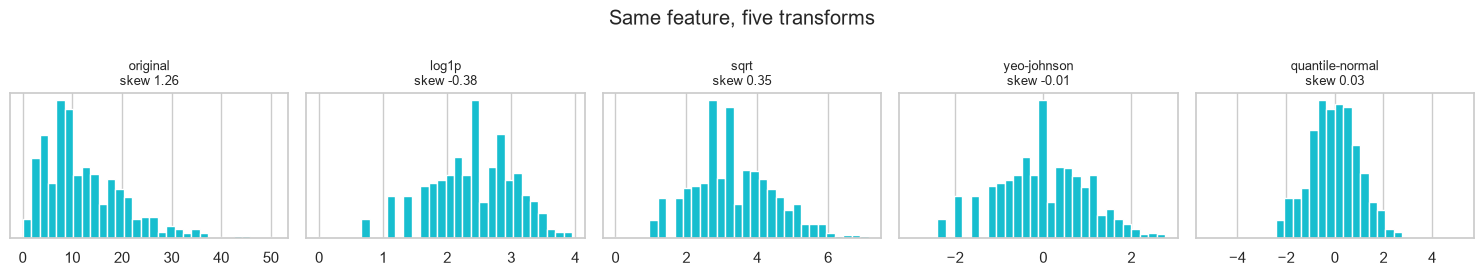

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8))
for ax, (name, values) in zip(axes, variants.items()):
    ax.hist(values, bins=30, color="tab:cyan")
    ax.set_title(f"{name}\nskew {pd.Series(values).skew():.2f}", fontsize=9)
    ax.set_yticks([])
fig.suptitle("Same feature, five transforms")
fig.tight_layout()
plt.show()

**Box–Cox fails on zeros, and `last_login_days` contains one.** A single zero in eight hundred rows is
enough to make it raise — this is the most common surprise with `PowerTransformer`, and the reason
Yeo–Johnson is the safer default.

In [24]:
print("zeros in last_login_days:", (skewed == 0).sum())

try:
    PowerTransformer(method="box-cox").fit_transform(skewed)
except ValueError as e:
    print("box-cox ->", str(e)[:80])

print("yeo-johnson handles it:",
      PowerTransformer(method="yeo-johnson").fit_transform(skewed).shape)

zeros in last_login_days: 1
box-cox -> The Box-Cox transformation can only be applied to strictly positive data
yeo-johnson handles it: (800, 1)


**When not to bother.** Tree-based models (Chapters 17–19) split on thresholds, and any monotonic transform
leaves the possible splits unchanged — so transforming features for a random forest changes nothing except
your ability to read them.

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

tree_frame = train_repaired[["last_login_days", "support_tickets", "churned"]].dropna()
X_raw = tree_frame[["last_login_days", "support_tickets"]]
X_log = np.log1p(X_raw)

for name, X_ in (("raw", X_raw), ("log1p", X_log)):
    scores = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
                             X_, tree_frame["churned"], cv=5, scoring="roc_auc")
    print(f"decision tree on {name:<6} mean AUC {scores.mean():.4f}")

decision tree on raw    mean AUC 0.6727
decision tree on log1p  mean AUC 0.6727


Identical to four decimal places, and not by luck: a monotonic transform cannot change which rows fall on
which side of *any* threshold, so the set of achievable trees is unchanged.

### 5.7 Putting Preprocessing in the Right Order

The steps are not commutative. This order is the one that avoids each step corrupting the next:

```text
 1. Split                        ------> 5.1   nothing before this touches the test set
 2. Remove duplicates            ------> 5.4   (or before the split, if duplicates could straddle it)
 3. Repair types                 ------> 5.4   text -> numeric, before any arithmetic
 4. Canonicalize categories      ------> 5.4   before encoding, or levels fragment
 5. Blank impossible values      ------> 5.3   before imputation, or they poison the statistics
 6. Impute                       ------> 5.2   fitted on train
 7. Engineer features            ------> Ch. 6 on repaired, complete data
 8. Encode categoricals          ------> 6.2   fitted on train
 9. Transform distributions      ------> 5.6   fitted on train
10. Scale                        ------> 5.5   fitted on train, and LAST
```

Three orderings that are not arbitrary:

| Constraint | Why |
|---|---|
| Repair types **before** anything numeric | `"12.5"` is not a number; arithmetic on it either fails or silently coerces |
| Blank impossible values **before** imputing | Otherwise age 199 is inside the mean used to fill the gaps (5.2.3) |
| Scale **last** | Every earlier step changes the distribution, so a scaler fitted before them is fitted to the wrong thing |

Step 2 has a genuine subtlety: deduplicating *after* the split leaves copies of the same row on both sides —
a leak. Deduplicating before the split is the safer default, and is what 4.9.1 and this chapter both do.

In [26]:
def preprocess(df, fitted=None):
    """Steps 2-5: deterministic repairs that learn nothing from the data."""
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = canonical_gender(out["gender"])
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


train_prepared = preprocess(train)
test_prepared = preprocess(test)

print("train:", train_prepared.shape, " test:", test_prepared.shape)
print("gender levels:", sorted(train_prepared["gender"].dropna().unique()))
print("age range    :", train_prepared["age"].min(), "-", train_prepared["age"].max())
print("total_charges dtype:", train_prepared["total_charges"].dtype)

train: (800, 14)  test: (200, 14)
gender levels: ['f', 'm']
age range    : 18.0 - 76.0
total_charges dtype: float64


Everything in `preprocess` is knowledge-free: it uses domain rules and type coercion, never a statistic
computed from the data. That is exactly why it can be applied to train and test identically. Steps 6, 8, 9
and 10 all *learn* something, so they belong in a `Pipeline` — which is 23.2.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["age", "tenure_months", "monthly_charges", "total_charges",
                    "support_tickets", "last_login_days", "satisfaction_score"]
categorical_features = ["gender", "city", "plan"]

learned_steps = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                          StandardScaler()), numeric_features),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical_features),
])

X_train = learned_steps.fit_transform(train_prepared)    # FIT on train
X_test = learned_steps.transform(test_prepared)           # APPLY to test

print("train matrix:", X_train.shape)
print("test  matrix:", X_test.shape, "-> same width, which is the point")

train matrix: (800, 23)
test  matrix: (200, 23) -> same width, which is the point


One object now holds every learned parameter — medians, means, standard deviations, category lists — and
applies them identically to any future data. That is the difference between a notebook that works and a
model that ships (3.9.3).

### 5.8 In Practice

#### 5.8.1 A worked case: does cleaning actually pay?

Preprocessing is usually justified by assertion. Measure it instead: build the same model on data cleaned
four different ways and compare on the same held-out test set.

In [28]:
from sklearn.linear_model import LogisticRegression

feature_set = ["age", "tenure_months", "monthly_charges", "support_tickets",
               "last_login_days", "satisfaction_score"]

def evaluate(name, train_X, train_y, test_X, test_y, model):
    model.fit(train_X, train_y)
    auc = roc_auc_score(test_y, model.predict_proba(test_X)[:, 1])
    print(f"{name:<38} n_train {len(train_X):>4}   test AUC {auc:.3f}")
    return auc


# A: drop every row with any missing value, no repairs at all.
a_tr = train[feature_set + ["churned"]].dropna()
a_te = test[feature_set + ["churned"]].dropna()
evaluate("A. dropna, no repairs", a_tr[feature_set], a_tr["churned"],
         a_te[feature_set], a_te["churned"],
         make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)))

A. dropna, no repairs                  n_train  666   test AUC 0.823


0.8232271325796505

In [29]:
# B: mean-impute everything, still no repairs - so age 199 is inside the mean.
b_model = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(),
                        LogisticRegression(max_iter=2000))
evaluate("B. mean impute, no repairs", train[feature_set], train["churned"],
         test[feature_set], test["churned"], b_model)

# C: repair impossible values first, then median-impute.
c_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                        LogisticRegression(max_iter=2000))
evaluate("C. repair, then median impute", train_prepared[feature_set], train_prepared["churned"],
         test_prepared[feature_set], test_prepared["churned"], c_model)

# D: C, plus missingness indicators.
d_model = make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(),
                        LogisticRegression(max_iter=2000))
evaluate("D. repair + median impute + indicators", train_prepared[feature_set],
         train_prepared["churned"], test_prepared[feature_set], test_prepared["churned"], d_model)

B. mean impute, no repairs             n_train  800   test AUC 0.830
C. repair, then median impute          n_train  800   test AUC 0.831


D. repair + median impute + indicators n_train  800   test AUC 0.830


0.8299418604651163

Read this honestly, because the honest reading is the useful one. B, C and D land within 0.001 AUC of each
other — on *this* dataset, with four impossible values out of eight hundred, careful repair buys
essentially **no** predictive accuracy over naive mean imputation.

What imputation *does* buy is visible in the first column: option A discards **134 training rows, 17% of
the data**, to end up slightly worse than every alternative. That is the reliable finding here, and it is
the one that generalizes.

The rest of the chapter's machinery earns its place on the risk side rather than the accuracy side. Four
bad values out of eight hundred move a mean by 0.27 years (5.2.3); four thousand bad values out of eight
hundred thousand would move it by the same negligible amount, and four bad values out of forty would
wreck it. **The cost of skipping repair is bounded by how bad the data is, and you do not know that until
you have looked.** On a column where 30% of the values were `-1` sentinels, option B would have been a
catastrophe and would have looked exactly this unremarkable in a notebook.

The defensible way to report this: *repair and impute because it is cheap and bounds the downside, keep the
indicators because missingness may be informative (5.2.1), and do not claim the cleaning improved the
score — on this data it did not.* Reporting "cleaning raised AUC by 0.001" as a win is how preprocessing
folklore gets manufactured.

#### 5.8.2 When to reach for what

| Situation | Do | Not |
|---|---|---|
| A value is physically impossible | Blank it, then impute (5.3) | Leave it; delete the row |
| A value is extreme but real | **Keep it** | Delete it because it looks untidy |
| Under ~5% missing, MCAR-ish | Median/mode impute | Drop the rows |
| Over ~40% missing in a column | Drop the column, or keep only its indicator | Impute — you are inventing most of it |
| Missingness might be informative | `add_indicator=True` | Impute silently |
| Blank means a genuine zero (5.4) | Fill with 0 | Impute the median |
| The model is a tree ensemble | Skip scaling and transforms entirely | Scale out of habit |
| The model is distance- or penalty-based | Scale, always | Assume the defaults handle it |
| Outliers are the thing you are predicting | Keep everything; see Ch. 21 | "Clean" them away |
| Any step that learns a statistic | Put it in a `Pipeline` (23.2) | Apply it to the full dataset first |

#### 5.8.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Scaler fitted on all data** | Test scores that never reproduce in production | 5.1 |
| **Imputation statistics drift** | Training medians baked in months ago no longer describe incoming data | 24.9 |
| **A new impossible value** | An upstream bug emits `-1`; the domain rules do not cover it and it flows into the model | 4.3.1 |
| **Sentinel meaning changes** | `0` meant "missing", then became a real measurement | 4.3.1 |
| **Category never seen in training** | The encoder raises, or silently drops the row | 6.2 |
| **Repairs live in a notebook** | The serving path re-implements them slightly differently and drifts | 3.9.3, 23.2 |

The last row is the one that actually bites teams, because it is an organizational failure rather than a
technical one: the cleaning logic exists twice, in two languages, maintained by two people. The only
durable fix is that **the artefact you deploy contains the preprocessing** — a fitted `Pipeline`, serialized
whole (24.8), so there is exactly one implementation and it is the one that was tested.

In [30]:
# --- 5. Data Preprocessing — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.